<a href="https://colab.research.google.com/github/dishanayak144/Housing-Prices-Project/blob/main/RES_BUY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn import model_selection
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [ ]:

bbsr_df= pd.read_excel('/content/drive/MyDrive/EAST INDIA DATA/RESIDENTIAL BUY 99 acres property data.xlsx', sheet_name='_BBSR')
cuttack_df= pd.read_excel('/content/drive/MyDrive/EAST INDIA DATA/RESIDENTIAL BUY 99 acres property data.xlsx', sheet_name='_CUTTACK')
patna_df= pd.read_excel('/content/drive/MyDrive/EAST INDIA DATA/RESIDENTIAL BUY 99 acres property data.xlsx', sheet_name='_PATNA')
kol_df= pd.read_excel('/content/drive/MyDrive/EAST INDIA DATA/RESIDENTIAL BUY 99 acres property data.xlsx', sheet_name='_KOLK')
ranchi_df= pd.read_excel('/content/drive/MyDrive/EAST INDIA DATA/RESIDENTIAL BUY 99 acres property data.xlsx', sheet_name='_RANCHI')



In [ ]:
kol_df.head()

,RESALE_NEW,PROP_TYPE,PRICE,Text After Delimiter,PER SQFT,T_PRICE,PER SQFT PRICE,AREA,BHK,STATUS,HIGHLIGHT 1,HIGHLIGHT 2,AMENITIES,OWNER TYPE,descPtag_undefined
0,RESALE,3 BHK Flat,1.00,10000000,12936,10000000.0,12936,773,3,Under Construction,south point within 250m,"manipal hospital, dhakuria within 1km",1,P S Realtors,"This beautiful 3 bhk flat in ballygunge place,..."
1,RESALE,3 BHK Flat,36.57,100000,3450,3657000.0,3450,1060,3,Ready To Move,Close to Metro Station,Close to School,1,Mithun Roy,Looking for a 3 bhk property for sale in kolka...
2,RESALE,3 BHK Flat,1.00,10000000,12936,10000000.0,12936,773,3,Under Construction,south point within 250m,"manipal hospital, dhakuria within 1km",1,P S Realtors,"This beautiful 3 bhk flat in ballygunge place,..."
3,RESALE,3 BHK Flat,36.57,100000,3450,3657000.0,3450,1060,3,Ready To Move,Close to Metro Station,Close to School,1,Mithun Roy,Looking for a 3 bhk property for sale in kolka...
4,RESALE,2 Bedroom House,24.00,100000,2446,2400000.0,2446,1190,2,Ready To Move,Private Garden,Fresh Construction,1,Owner,"Ready to move, independent house with 2 floors..."


# **KOLKATA**

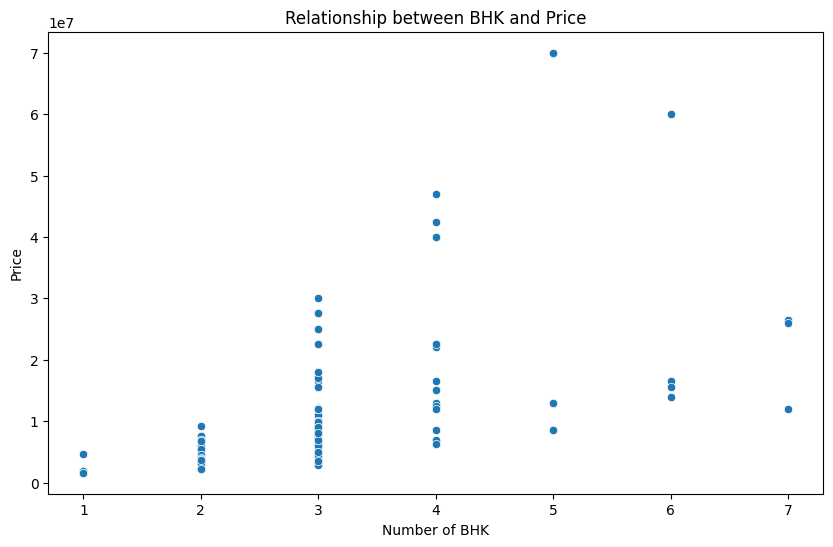

                 T_PRICE       BHK  PER SQFT PRICE  AMENITIES      AREA
T_PRICE         1.000000  0.590106        0.719158   0.005449  0.457553
BHK             0.590106  1.000000        0.381421  -0.032895  0.443997
PER SQFT PRICE  0.719158  0.381421        1.000000  -0.064497  0.039777
AMENITIES       0.005449 -0.032895       -0.064497   1.000000 -0.055132
AREA            0.457553  0.443997        0.039777  -0.055132  1.000000


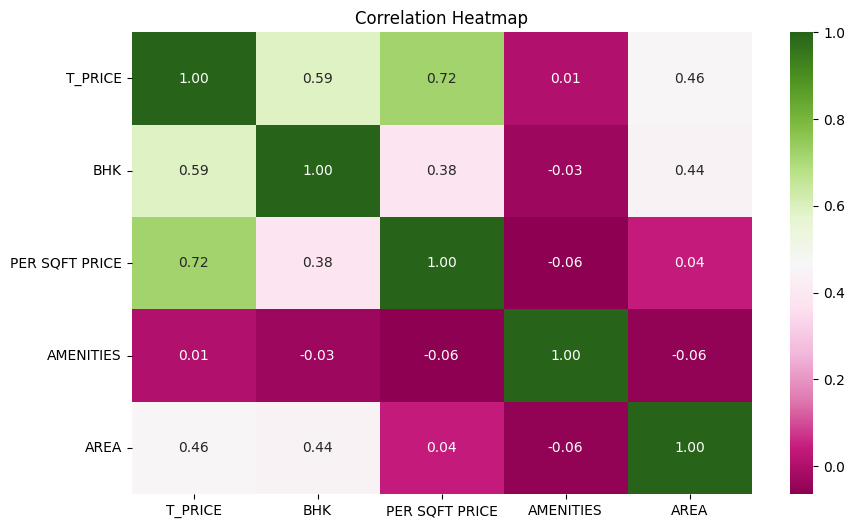

In [ ]:

# Assuming your dataframe is named 'df' and has columns 'bhk' and 'price'
# Replace 'df' with the actual name of your dataframe

# Create the scatter plot
plt.figure(figsize=(10, 6))  # Adjust figure size as needed
sns.scatterplot(x='BHK', y='T_PRICE', data=kol_df)
plt.title('Relationship between BHK and Price')
plt.xlabel('Number of BHK')
plt.ylabel('Price')
plt.show()





import pandas as pd

# Assuming your dataframe is named 'df' and has columns 'T_PRICE', 'BHK', 'PER SQFT PRICE', and 'AMENITIES'
# Replace 'df' with the actual name of your dataframe if it's different

# Select the relevant columns
selected_columns = ['T_PRICE', 'BHK', 'PER SQFT PRICE', 'AMENITIES', 'AREA']
subset_df = kol_df[selected_columns]

# Calculate the correlation matrix
correlation_matrix = subset_df.corr()

# Display the correlation matrix
print(correlation_matrix)





# Assuming your dataframe is named 'df' and has columns 'T_PRICE', 'BHK', 'PER SQFT PRICE', and 'AMENITIES'
# Replace 'df' with the actual name of your dataframe if it's different

# Select the relevant columns
selected_columns = ['T_PRICE', 'BHK', 'PER SQFT PRICE', 'AMENITIES', 'AREA']
subset_df = kol_df[selected_columns]

# Calculate the correlation matrix
correlation_matrix = subset_df.corr()

# Create the heatmap
plt.figure(figsize=(10, 6))  # Adjust figure size as needed
sns.heatmap(correlation_matrix, annot=True, cmap='PiYG', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Filter data for properties in Kolkata (kol_df)
filtered_kol_df = kol_df

# Select features and target variable, including 'BHK' and 'AMENITIES'
features = ['AREA', 'PER SQFT PRICE', 'BHK', 'AMENITIES']
target = 'T_PRICE'
X = filtered_kol_df[features]
y = filtered_kol_df[target]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the Gradient Boosting model
model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

# Print predicted prices for the test set (optional)
print("\nPredicted Prices:")
for i in range(len(y_pred)):
    print(f"Actual Price: {y_test.iloc[i]}, Predicted Price: {y_pred[i]}")

# Print feature importances
print("\nFeature Importances:")
for feature, importance in zip(features, model.feature_importances_):
    print(f"{feature}: {importance}")

Mean Squared Error: 9248944827681.812
R-squared: 0.96521286104492

Predicted Prices:
Actual Price: 9000000.0, Predicted Price: 9478506.570248246
Actual Price: 17000000.0, Predicted Price: 14642612.722924316
Actual Price: 16500000.0, Predicted Price: 17186646.597530853
Actual Price: 7000000.0, Predicted Price: 6663242.618155327
Actual Price: 5800000.0, Predicted Price: 5129542.683411249
Actual Price: 7000000.0, Predicted Price: 10549332.714744713
Actual Price: 7400000.0, Predicted Price: 8152770.406022468
Actual Price: 8500000.0, Predicted Price: 11450819.806864543
Actual Price: 18000000.0, Predicted Price: 15912768.46083512
Actual Price: 8500000.0, Predicted Price: 10437951.34978631
Actual Price: 1600000.0, Predicted Price: 1090970.073497116
Actual Price: 60000000.0, Predicted Price: 49146270.453514844
Actual Price: 8500000.0, Predicted Price: 9324870.512708768
Actual Price: 13000000.0, Predicted Price: 12602878.26382216
Actual Price: 1600000.0, Predicted Price: 1090970.073497116
Actua

Interpretation:

AREA: This feature has an importance score of approximately 0.44, indicating that it is a significant factor in determining property prices. A larger area generally leads to a higher predicted price, all other factors being equal.
PER SQFT PRICE: This feature has the highest importance score of approximately 0.52, suggesting that it is the most influential factor in the model's predictions. A higher price per square foot strongly correlates with a higher predicted price.
BHK: This feature has a moderate importance score of approximately 0.04. It indicates that the number of bedrooms (BHK) has a noticeable impact on property prices, but not as much as the area or price per square foot.
AMENITIES: This feature has a very low importance score of approximately 0.0004. This suggests that the presence or absence of amenities has a negligible impact on the model's predictions of property prices, at least within the dataset you're using.
In simpler terms:

The model relies most heavily on the price per square foot and the area of the property to predict its price.
The number of bedrooms also plays a role, but to a lesser extent.
The amenities feature has very little influence on the predicted price, according to the model.

# **BHUBANESWAR**

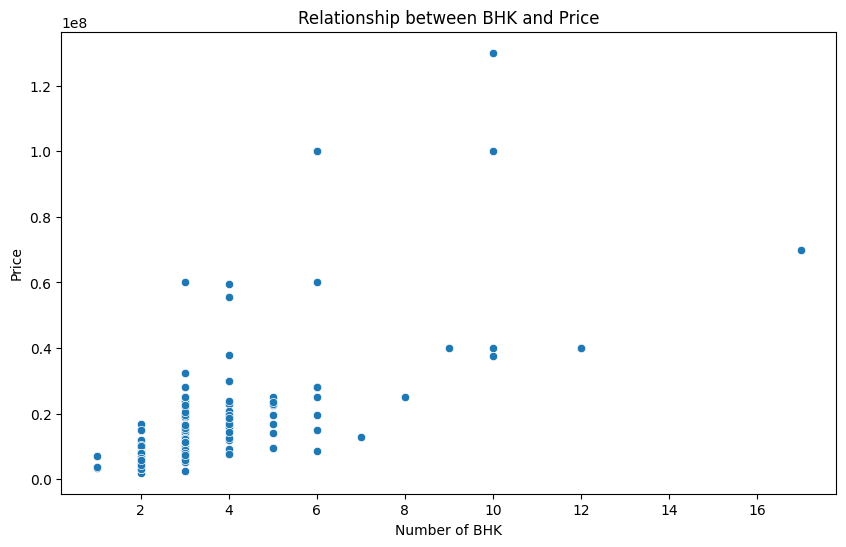

                 T_PRICE       BHK  PER SQFT PRICE  AMENITIES      AREA
T_PRICE         1.000000  0.672836        0.722765  -0.034006  0.797574
BHK             0.672836  1.000000        0.524511  -0.056998  0.516767
PER SQFT PRICE  0.722765  0.524511        1.000000  -0.080895  0.291002
AMENITIES      -0.034006 -0.056998       -0.080895   1.000000 -0.024643
AREA            0.797574  0.516767        0.291002  -0.024643  1.000000


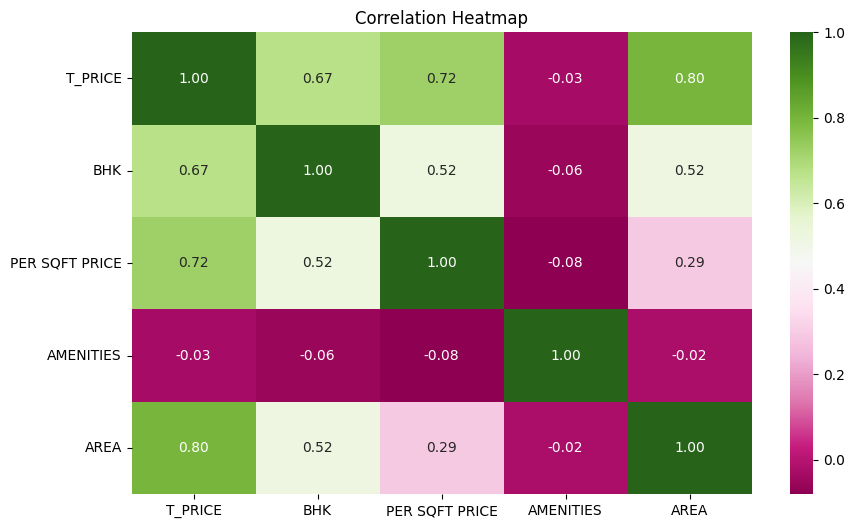

In [ ]:
# Assuming your dataframe is named 'df' and has columns 'bhk' and 'price'
# Replace 'df' with the actual name of your dataframe

# Create the scatter plot
plt.figure(figsize=(10, 6))  # Adjust figure size as needed
sns.scatterplot(x='BHK', y='T_PRICE', data=bbsr_df)
plt.title('Relationship between BHK and Price')
plt.xlabel('Number of BHK')
plt.ylabel('Price')
plt.show()





# Assuming your dataframe is named 'df' and has columns 'T_PRICE', 'BHK', 'PER SQFT PRICE', and 'AMENITIES'
# Replace 'df' with the actual name of your dataframe if it's different

# Select the relevant columns
selected_columns = ['T_PRICE', 'BHK', 'PER SQFT PRICE', 'AMENITIES', 'AREA']
subset_df = bbsr_df[selected_columns]

# Calculate the correlation matrix
correlation_matrix = subset_df.corr()

# Display the correlation matrix
print(correlation_matrix)





# Select the relevant columns
selected_columns = ['T_PRICE', 'BHK', 'PER SQFT PRICE', 'AMENITIES', 'AREA']
subset_df = bbsr_df[selected_columns]

# Calculate the correlation matrix
correlation_matrix = subset_df.corr()

# Create the heatmap
plt.figure(figsize=(10, 6))  # Adjust figure size as needed
sns.heatmap(correlation_matrix, annot=True, cmap='PiYG', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Use bbsr_df instead of kol_df
filtered_bbsr_df = bbsr_df

# Select features and target variable, including 'BHK' and 'AMENITIES'
features = ['AREA', 'PER SQFT PRICE', 'BHK', 'AMENITIES']
target = 'T_PRICE'
X = filtered_bbsr_df[features]
y = filtered_bbsr_df[target]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the Gradient Boosting model
model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

# Print predicted prices for the test set (optional)
print("\nPredicted Prices:")
for i in range(len(y_pred)):
    print(f"Actual Price: {y_test.iloc[i]}, Predicted Price: {y_pred[i]}")

# Print feature importances
print("\nFeature Importances:")
for feature, importance in zip(features, model.feature_importances_):
    print(f"{feature}: {importance}")

Mean Squared Error: 43354130101331.7
R-squared: 0.8360014203605259

Predicted Prices:
Actual Price: 130000000, Predicted Price: 81852883.93539849
Actual Price: 16500000, Predicted Price: 16489675.000709789
Actual Price: 6100000, Predicted Price: 6573421.658571731
Actual Price: 5800000, Predicted Price: 6891678.788549295
Actual Price: 15000000, Predicted Price: 13543533.50415226
Actual Price: 14000000, Predicted Price: 13619903.939131629
Actual Price: 28000000, Predicted Price: 25958231.59888487
Actual Price: 5600000, Predicted Price: 5699468.723855626
Actual Price: 40000000, Predicted Price: 55051045.732311815
Actual Price: 8500000, Predicted Price: 8603642.547085352
Actual Price: 15000000, Predicted Price: 19403401.797569294
Actual Price: 16700000, Predicted Price: 13759996.631680273
Actual Price: 9500000, Predicted Price: 10597107.125806775
Actual Price: 12000000, Predicted Price: 11409423.128815096
Actual Price: 4200000, Predicted Price: 4264923.0796877295
Actual Price: 7500000, Pre

**Interpretation:**

AREA: With an importance score of approximately 0.34, the area of the property is a significant factor in determining prices in Bhubaneswar. Larger areas generally lead to higher predicted prices, but its influence is slightly less compared to the "PER SQFT PRICE" feature.
PER SQFT PRICE: This feature has the highest importance score of approximately 0.49, indicating that it is the most influential factor in the model's predictions. A higher price per square foot strongly correlates with a higher predicted price.
BHK: The number of bedrooms (BHK) has a moderate importance score of approximately 0.17. This suggests that BHK has a noticeable impact on property prices in Bhubaneswar, but not as much as the area or price per square foot. However, its importance is notably higher compared to the model trained on the kol_df dataset.
AMENITIES: Similar to the kol_df model, the presence or absence of amenities has a very low importance score (approximately 0.0005). This suggests that amenities have a negligible impact on the model's predictions of property prices in Bhubaneswar.

**Comparison with kol_df Model:**

AREA and PER SQFT PRICE: Both features remain significant in both models, but their relative importance has shifted slightly. In the bbsr_df model, "PER SQFT PRICE" retains its dominance, but "AREA" has a slightly lower importance compared to the kol_df model.
BHK: The importance of BHK is considerably higher in the bbsr_df model (0.17) compared to the kol_df model (0.04). This suggests that the number of bedrooms might be a more influential factor in determining property prices in Bhubaneswar compared to Kolkata.
AMENITIES: Amenities remain a negligible factor in both models.


# **CUTTACK**

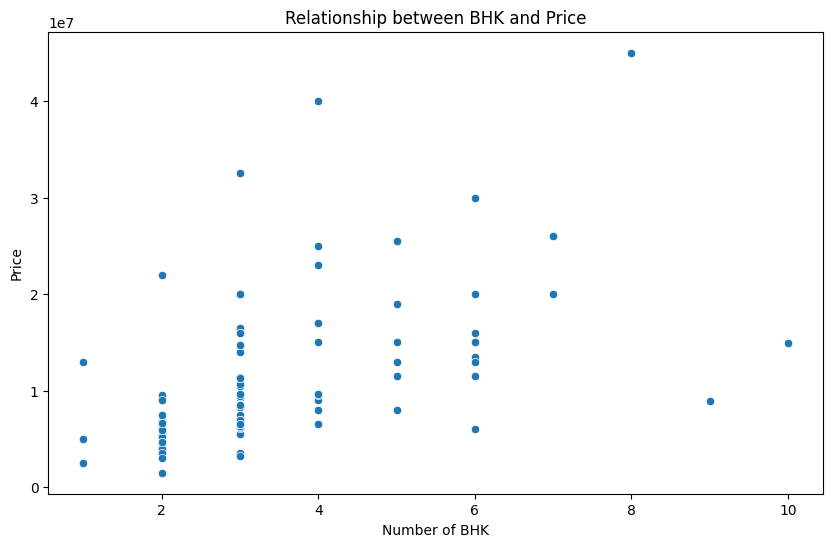

                 T_PRICE       BHK  PER SQFT PRICE  AMENITIES      AREA
T_PRICE         1.000000  0.549302        0.376378  -0.113878  0.228386
BHK             0.549302  1.000000        0.256451  -0.258222 -0.001711
PER SQFT PRICE  0.376378  0.256451        1.000000  -0.158978 -0.308834
AMENITIES      -0.113878 -0.258222       -0.158978   1.000000  0.126900
AREA            0.228386 -0.001711       -0.308834   0.126900  1.000000


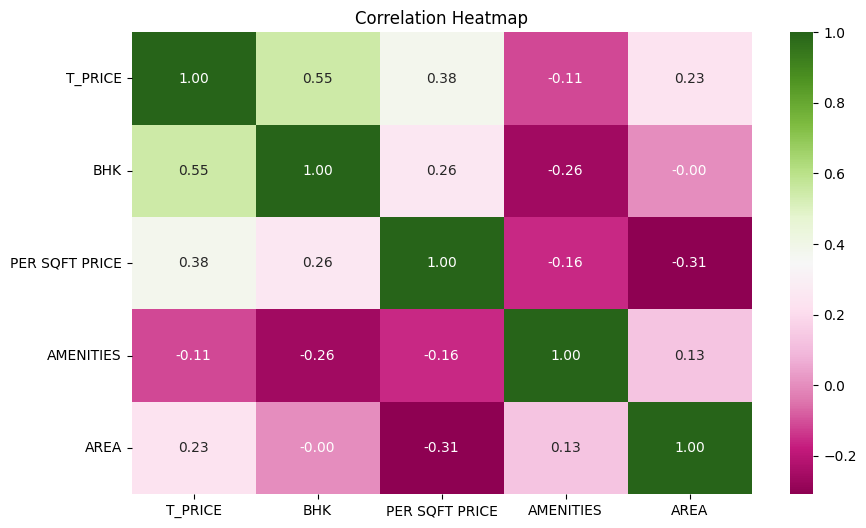

In [ ]:
# Create the scatter plot
plt.figure(figsize=(10, 6))  # Adjust figure size as needed
sns.scatterplot(x='BHK', y='T_PRICE', data=cuttack_df)
plt.title('Relationship between BHK and Price')
plt.xlabel('Number of BHK')
plt.ylabel('Price')
plt.show()



# Select the relevant columns
selected_columns = ['T_PRICE', 'BHK', 'PER SQFT PRICE', 'AMENITIES', 'AREA']
subset_df = cuttack_df[selected_columns]

# Calculate the correlation matrix
correlation_matrix = subset_df.corr()

# Display the correlation matrix
print(correlation_matrix)


# Select the relevant columns
selected_columns = ['T_PRICE', 'BHK', 'PER SQFT PRICE', 'AMENITIES', 'AREA']
subset_df = cuttack_df[selected_columns]

# Calculate the correlation matrix
correlation_matrix = subset_df.corr()

# Create the heatmap
plt.figure(figsize=(10, 6))  # Adjust figure size as needed
sns.heatmap(correlation_matrix, annot=True, cmap='PiYG', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Use cuttack_df instead of kol_df
filtered_cuttack_df = cuttack_df

# Select features and target variable, including 'BHK' and 'AMENITIES'
features = ['AREA', 'PER SQFT PRICE', 'BHK', 'AMENITIES']
target = 'T_PRICE'
X = filtered_cuttack_df[features]
y = filtered_cuttack_df[target]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the Gradient Boosting model
model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

# Print predicted prices for the test set (optional)
print("\nPredicted Prices:")
for i in range(len(y_pred)):
    print(f"Actual Price: {y_test.iloc[i]}, Predicted Price: {y_pred[i]}")

# Print feature importances
print("\nFeature Importances:")
for feature, importance in zip(features, model.feature_importances_):
    print(f"{feature}: {importance}")

Mean Squared Error: 9834926187789.965
R-squared: 0.8038741196252824

Predicted Prices:
Actual Price: 7469000, Predicted Price: 7530210.3709385125
Actual Price: 7400000, Predicted Price: 7464606.60733765
Actual Price: 26000000, Predicted Price: 23112328.927020323
Actual Price: 6500000, Predicted Price: 6447422.978208572
Actual Price: 6500000, Predicted Price: 6431994.203747159
Actual Price: 10700000, Predicted Price: 9967222.668486003
Actual Price: 4200000, Predicted Price: 4089884.2344116094
Actual Price: 40000000, Predicted Price: 28576124.11458851
Actual Price: 8300000, Predicted Price: 8172088.475915481
Actual Price: 8500000, Predicted Price: 8253574.40838393
Actual Price: 11400000, Predicted Price: 18454965.092715383
Actual Price: 6909000, Predicted Price: 6939489.735763712
Actual Price: 9200000, Predicted Price: 11567113.570793949
Actual Price: 9456000, Predicted Price: 9730171.898072982
Actual Price: 9300000, Predicted Price: 8882952.18013199
Actual Price: 6631000, Predicted Pric

*Cuttack Feature Importances:*

AREA: 0.6050349861066746
PER SQFT PRICE: 0.3099578599862632
BHK: 0.0830597642951103
AMENITIES: 0.0019473896119517758

*Bhubaneswar Feature Importances:*

AREA: 0.3416429037483864
PER SQFT PRICE: 0.48511748526050164
BHK: 0.1727439424158632
AMENITIES: 0.0004956685752488201

Key Observations:

AREA: In Cuttack, the AREA feature has a much higher importance (0.61) compared to Bhubaneswar (0.34). This suggests that the size of the property plays a more significant role in determining prices in Cuttack.

PER SQFT PRICE: While still important in Cuttack (0.31), the PER SQFT PRICE feature has a lower importance compared to Bhubaneswar (0.49). This indicates that the price per square foot might be a slightly less dominant factor in Cuttack's property prices.

BHK: The BHK feature has a similar level of importance in both cities, although it's slightly higher in Bhubaneswar (0.17) compared to Cuttack (0.08). This suggests that the number of bedrooms has a moderate influence on property prices in both locations.

AMENITIES: In both cities, AMENITIES have a negligible impact on property prices, with importance scores close to 0.

# **PATNA**

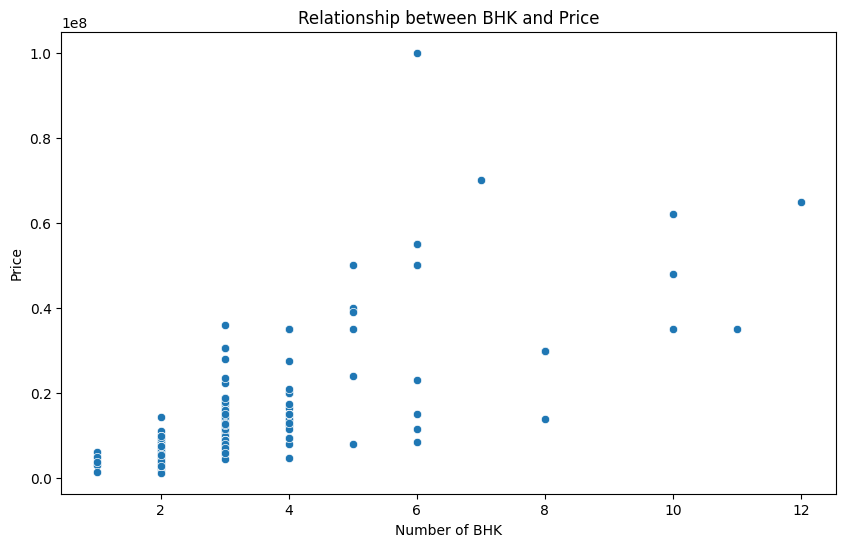

                 T_PRICE       BHK  PER SQFT PRICE      AREA
T_PRICE         1.000000  0.730859        0.813592  0.708997
BHK             0.730859  1.000000        0.579000  0.691390
PER SQFT PRICE  0.813592  0.579000        1.000000  0.327028
AREA            0.708997  0.691390        0.327028  1.000000


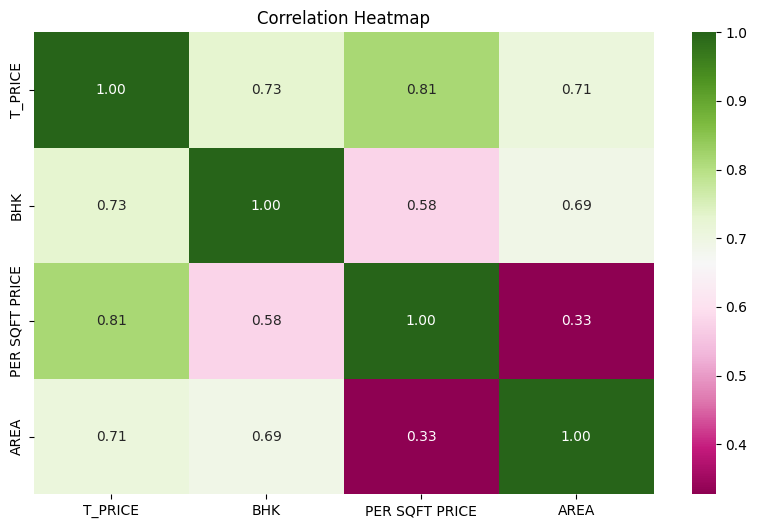

In [ ]:
# Create the scatter plot
plt.figure(figsize=(10, 6))  # Adjust figure size as needed
sns.scatterplot(x='BHK', y='T_PRICE', data=patna_df)
plt.title('Relationship between BHK and Price')
plt.xlabel('Number of BHK')
plt.ylabel('Price')
plt.show()






# Select the relevant columns
selected_columns = ['T_PRICE', 'BHK', 'PER SQFT PRICE', 'AREA']
subset_df = patna_df[selected_columns]

# Calculate the correlation matrix
correlation_matrix = subset_df.corr()

# Display the correlation matrix
print(correlation_matrix)





# Select the relevant columns
selected_columns = ['T_PRICE', 'BHK', 'PER SQFT PRICE', 'AREA']
subset_df = patna_df[selected_columns]

# Calculate the correlation matrix
correlation_matrix = subset_df.corr()

# Create the heatmap
plt.figure(figsize=(10, 6))  # Adjust figure size as needed
sns.heatmap(correlation_matrix, annot=True, cmap='PiYG', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Use patna_df instead of cuttack_df
filtered_patna_df = patna_df

# Select features and target variable
# If 'AMENITIES' column is not present in patna_df, remove it from the features list
features = ['AREA', 'PER SQFT PRICE', 'BHK']  # Adjust if needed
target = 'T_PRICE'
X = filtered_patna_df[features]
y = filtered_patna_df[target]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the Gradient Boosting model
model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

# Print predicted prices for the test set (optional)
print("\nPredicted Prices:")
for i in range(len(y_pred)):
    print(f"Actual Price: {y_test.iloc[i]}, Predicted Price: {y_pred[i]}")

# Print feature importances
print("\nFeature Importances:")
for feature, importance in zip(features, model.feature_importances_):
    print(f"{feature}: {importance}")

Mean Squared Error: 23430701773526.04
R-squared: 0.8799815031786077

Predicted Prices:
Actual Price: 7500000.0, Predicted Price: 7935406.376547815
Actual Price: 5500000.0, Predicted Price: 7383323.437920838
Actual Price: 9500000.0, Predicted Price: 9971421.780958926
Actual Price: 8500000.0, Predicted Price: 9136309.411061635
Actual Price: 7400000.0, Predicted Price: 7924416.344250967
Actual Price: 6500000.0, Predicted Price: 7028969.774684125
Actual Price: 8651000.0, Predicted Price: 8288831.34893069
Actual Price: 14000000.0, Predicted Price: 12471647.027942076
Actual Price: 7288000.0, Predicted Price: 7649109.585489504
Actual Price: 11000000.0, Predicted Price: 14644679.435798617
Actual Price: 8600000.0, Predicted Price: 9120359.243149329
Actual Price: 7800000.0, Predicted Price: 7913054.424715927
Actual Price: 6200000.0, Predicted Price: 9946342.922604896
Actual Price: 4200000.0, Predicted Price: 4042328.828678434
Actual Price: 9200000.0, Predicted Price: 9207405.293118
Actual Price:

Patna Feature Importances:

AREA: 0.5557477477466893
PER SQFT PRICE: 0.3569688477890325
BHK: 0.08728340446427806

Bhubaneswar Feature Importances:

AREA: 0.3416429037483864
PER SQFT PRICE: 0.48511748526050164
BHK: 0.1727439424158632
AMENITIES: 0.0004956685752488201

Key Observations:

AREA: In Patna, the AREA feature has a higher importance (0.56) compared to Bhubaneswar (0.34). This suggests that the size of the property plays a more significant role in determining prices in Patna.

PER SQFT PRICE: While still important in Patna (0.36), the PER SQFT PRICE feature has a lower importance compared to Bhubaneswar (0.49). This indicates that the price per square foot might be a slightly less dominant factor in Patna's property prices.

BHK: The BHK feature has a much lower importance in Patna (0.09) compared to Bhubaneswar (0.17). This suggests that the number of bedrooms might be a less influential factor in determining property prices in Patna compared to Bhubaneswar.

AMENITIES: The AMENITIES feature was not included in the Patna model due to potential data limitations, while it has a negligible impact in Bhubaneswar.

# **RANCHI**

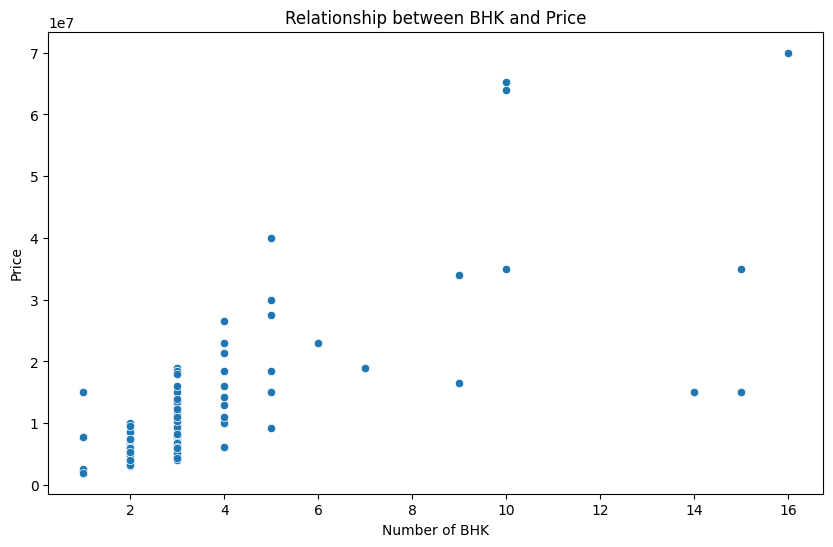

                 T_PRICE       BHK  PER SQFT PRICE      AREA
T_PRICE         1.000000  0.722922        0.001337  0.447412
BHK             0.722922  1.000000       -0.089730  0.290723
PER SQFT PRICE  0.001337 -0.089730        1.000000 -0.096467
AREA            0.447412  0.290723       -0.096467  1.000000


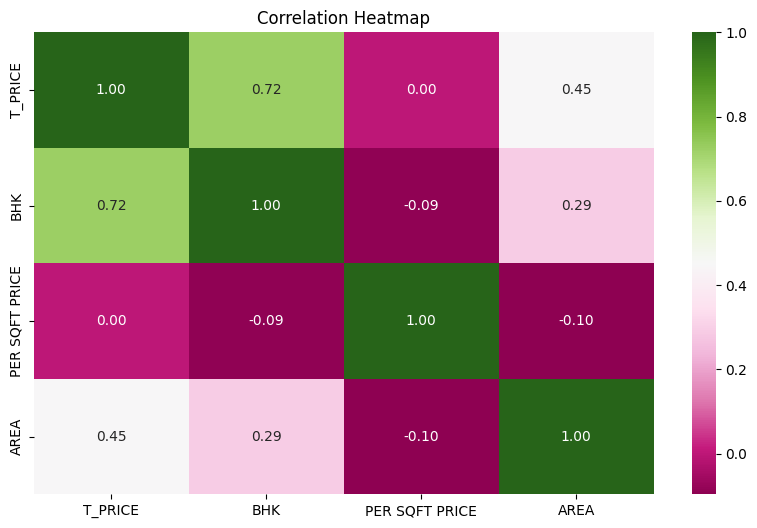

In [ ]:
# Create the scatter plot
plt.figure(figsize=(10, 6))  # Adjust figure size as needed
sns.scatterplot(x='BHK', y='T_PRICE', data=ranchi_df)
plt.title('Relationship between BHK and Price')
plt.xlabel('Number of BHK')
plt.ylabel('Price')
plt.show()





# Select the relevant columns
selected_columns = ['T_PRICE', 'BHK', 'PER SQFT PRICE', 'AREA']
subset_df = ranchi_df[selected_columns]

# Calculate the correlation matrix
correlation_matrix = subset_df.corr()

# Display the correlation matrix
print(correlation_matrix)






# Select the relevant columns
selected_columns = ['T_PRICE', 'BHK', 'PER SQFT PRICE', 'AREA']
subset_df = ranchi_df[selected_columns]

# Calculate the correlation matrix
correlation_matrix = subset_df.corr()

# Create the heatmap
plt.figure(figsize=(10, 6))  # Adjust figure size as needed
sns.heatmap(correlation_matrix, annot=True, cmap='PiYG', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Use ranchi_df instead of patna_df
filtered_ranchi_df = ranchi_df

# Select features and target variable
# If 'AMENITIES' column is not present in ranchi_df, remove it from the features list
features = ['AREA', 'PER SQFT PRICE', 'BHK']  # Adjust if needed
target = 'T_PRICE'
X = filtered_ranchi_df[features]
y = filtered_ranchi_df[target]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the Gradient Boosting model
model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

# Print predicted prices for the test set (optional)
print("\nPredicted Prices:")
for i in range(len(y_pred)):
    print(f"Actual Price: {y_test.iloc[i]}, Predicted Price: {y_pred[i]}")

# Print feature importances
print("\nFeature Importances:")
for feature, importance in zip(features, model.feature_importances_):
    print(f"{feature}: {importance}")

Mean Squared Error: 1022070514429.7524
R-squared: 0.984204750947552

Predicted Prices:
Actual Price: 6900000.0, Predicted Price: 6662857.527639559
Actual Price: 12300000.0, Predicted Price: 14338574.993789695
Actual Price: 7050000.0, Predicted Price: 7152072.600650447
Actual Price: 6000000.0, Predicted Price: 5832410.13630395
Actual Price: 6434999.999999999, Predicted Price: 6362969.738274754
Actual Price: 5600000.0, Predicted Price: 5461399.867752539
Actual Price: 5550000.0, Predicted Price: 5927507.317517044
Actual Price: 6200000.0, Predicted Price: 6339191.104377868
Actual Price: 6900000.0, Predicted Price: 6651693.12694011
Actual Price: 16000000.0, Predicted Price: 12623758.010205673
Actual Price: 6800000.0, Predicted Price: 6745524.819973382
Actual Price: 11000000.0, Predicted Price: 10735332.534151543
Actual Price: 18500000.0, Predicted Price: 17494284.582768552
Actual Price: 7500000.0, Predicted Price: 7087567.381298964
Actual Price: 9500000.0, Predicted Price: 10035995.72163219

**Ranchi Feature Importances:**

AREA: 0.43031650223511203
PER SQFT PRICE: 0.20009408063254255
BHK: 0.36958941713234544

**Bhubaneswar Feature Importances:**

AREA: 0.3416429037483864
PER SQFT PRICE: 0.48511748526050164
BHK: 0.1727439424158632
AMENITIES: 0.0004956685752488201

**Patna Feature Importances:**

AREA: 0.5557477477466893
PER SQFT PRICE: 0.3569688477890325
BHK: 0.08728340446427806

**Key Observations:**

**AREA:** In Patna, AREA has the highest importance (0.56), followed by Ranchi (0.43) and then Bhubaneswar (0.34). This suggests that the size of the property is a crucial factor in determining prices in Patna and Ranchi, while it's still significant but relatively less important in Bhubaneswar.

**PER SQFT PRICE: **In Bhubaneswar, PER SQFT PRICE has the highest importance (0.49), followed by Patna (0.36) and then Ranchi (0.20). This indicates that the price per square foot is a dominant factor in Bhubaneswar, while it's still important but less influential in Patna and Ranchi.

**BHK:** In Ranchi, BHK has the highest importance (0.37), significantly higher than in Bhubaneswar (0.17) and Patna (0.09). This suggests that the number of bedrooms might be a more crucial factor in determining property prices in Ranchi compared to the other two cities.

**AMENITIES:** The AMENITIES feature was not included in the Ranchi and Patna models, while it has a negligible impact in Bhubaneswar. This could be due to data limitations or the fact that amenities might not be as significant a factor in these cities.

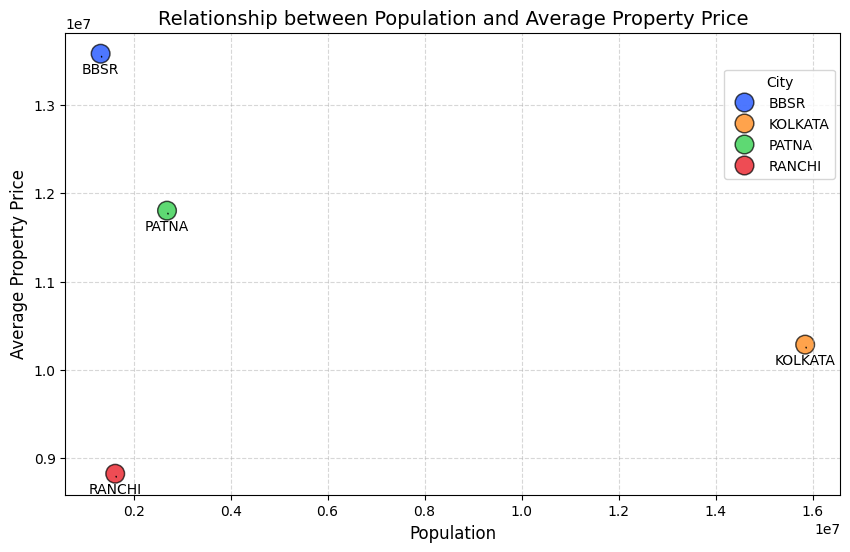

In [ ]:
bbsr_avg_price = bbsr_df['T_PRICE'].mean()  # or median()
kol_avg_price = kol_df['T_PRICE'].mean()
patna_avg_price = patna_df['T_PRICE'].mean()
ranchi_avg_price = ranchi_df['T_PRICE'].mean()


import pandas as pd
data = {
       'City': ['BBSR', 'KOLKATA', 'PATNA', 'RANCHI'],
       'Avg_Price': [bbsr_avg_price, kol_avg_price, patna_avg_price, ranchi_avg_price],
       'Population': [1320908, 15845219, 2689544, 1621724]
}
viz_df = pd.DataFrame(data)

import pandas as pd
data = {
       'City': ['BBSR', 'KOLKATA', 'PATNA', 'RANCHI'],
       'Avg_Price': [bbsr_avg_price, kol_avg_price, patna_avg_price, ranchi_avg_price],
       'Population': [1320908, 15845219, 2689544, 1621724]
}
viz_df = pd.DataFrame(data)


plt.figure(figsize=(10, 6))
sns.scatterplot(x='Population', y='Avg_Price', data=viz_df, hue='City',
                s=180, alpha= 0.7, palette='bright', edgecolor='black')  # Enhancements

for i, row in viz_df.iterrows():
    plt.annotate(row['City'], (row['Population'], row['Avg_Price']),
                 xytext=(row['Population'], row['Avg_Price'] - 100000),  # Adjust offset as needed
                 ha='center', va='top',  # Horizontal and vertical alignment
                 arrowprops=dict(arrowstyle='-', connectionstyle='arc3,rad=0.2'))  # Customize arrow style

plt.title('Relationship between Population and Average Property Price', fontsize=14)
plt.xlabel('Population', fontsize=12)
plt.ylabel('Average Property Price', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)  # Add gridlines
plt.legend(title='City', fontsize=10, loc='upper left',
                    bbox_to_anchor=(0.85, 0.92), borderaxespad=0.)

plt.show()

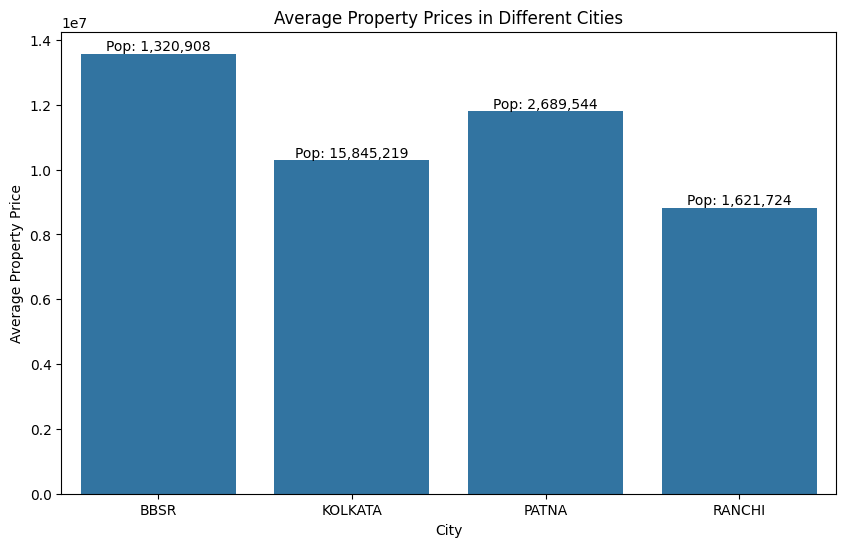

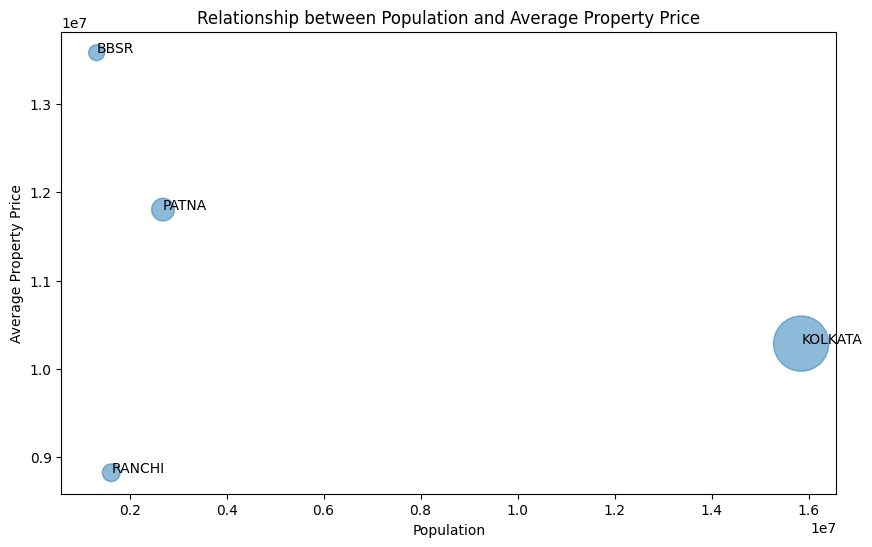

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Calculate average prices for each city
bbsr_avg_price = bbsr_df['T_PRICE'].mean()
kol_avg_price = kol_df['T_PRICE'].mean()
patna_avg_price = patna_df['T_PRICE'].mean()
ranchi_avg_price = ranchi_df['T_PRICE'].mean()

# Create a DataFrame for visualization
data = {
    'City': ['BBSR', 'KOLKATA', 'PATNA', 'RANCHI'],
    'Avg_Price': [bbsr_avg_price, kol_avg_price, patna_avg_price, ranchi_avg_price],
    'Population': [1320908, 15845219, 2689544, 1621724]
}
viz_df = pd.DataFrame(data)

# Create the bubble chart
plt.figure(figsize=(10, 6))
plt.scatter(viz_df['Population'], viz_df['Avg_Price'], s=viz_df['Population'] / 10000, alpha=0.5)  # Adjust bubble size as needed
plt.title('Relationship between Population and Average Property Price')
plt.xlabel('Population')
plt.ylabel('Average Property Price')

# Add city labels to the bubbles
for i, row in viz_df.iterrows():
    plt.annotate(row['City'], (row['Population'], row['Avg_Price']))

plt.show()